## Amazon Sales Data Analysis using Python

##### This project analyzes Amazon sales data to understand revenue trends, product performance, customer behavior, and payment patterns using Pandas, NumPy, and Matplotlib.

**Import Libraries** - Imports all required Python libraries (Pandas, NumPy, Matplotlib, etc.) needed for data analysis and visualization.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset** - Loads the dataset file into a pandas DataFrame for analysis. 

In [13]:
df = pd.read_csv("amazon_sales.csv")

**Display DataFrame** - Shows the dataset stored in df to view the table of data. 

## Data Cleaning

In [62]:
# Check dataset structure
df.info()

# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Dataset shape after cleaning
print("Dataset shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          500 non-null    int64         
 1   order_date        500 non-null    datetime64[us]
 2   product_id        500 non-null    int64         
 3   product_category  500 non-null    str           
 4   price             500 non-null    float64       
 5   discount_percent  500 non-null    int64         
 6   quantity_sold     500 non-null    int64         
 7   customer_region   500 non-null    str           
 8   payment_method    500 non-null    str           
 9   rating            500 non-null    float64       
 10  review_count      500 non-null    int64         
 11  discounted_price  500 non-null    float64       
 12  total_revenue     500 non-null    float64       
 13  profit            500 non-null    float64       
 14  year              500 non-null    int

### Data Cleaning Summary

• Checked dataset structure  
• Verified missing values  
• Removed duplicate rows  
• Prepared dataset for analysis

In [14]:
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,23.1760
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,60.5200
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,39.6640
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,63.2320
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,40.3360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,2023-04-20,2815,Books,236.88,5,3,Europe,UPI,3.7,285,225.04,675.12,33.7560
496,497,2023-10-26,3798,Fashion,220.02,10,5,Asia,UPI,3.1,312,198.02,990.10,49.5050
497,498,2023-11-21,4860,Electronics,317.44,5,1,Europe,Credit Card,4.0,153,301.57,301.57,15.0785
498,499,2023-11-06,3441,Home & Kitchen,331.01,10,1,Middle East,Debit Card,1.6,191,297.91,297.91,14.8955


**Dataset Shape** - Returns the number of rows and columns in the dataset. 

In [15]:
df.shape

(500, 14)

**Column Names** - Displays the names of all columns present in the dataset.

In [16]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue', 'profit'],
      dtype='str')

**Data Types** - Shows the data type of each column in the dataset.

In [17]:
df.dtypes

order_id              int64
order_date              str
product_id            int64
product_category        str
price               float64
discount_percent      int64
quantity_sold         int64
customer_region         str
payment_method          str
rating              float64
review_count          int64
discounted_price    float64
total_revenue       float64
profit              float64
dtype: object

**Object Type** - Shows the type of object stored in df (Pandas DataFrame).

In [18]:
type(df)

pandas.DataFrame

**First Rows Preview** - Displays the first 5 rows of the dataset.

In [19]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,23.176
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,60.520
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,39.664
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,63.232
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,40.336


**Last Rows Preview** - Displays the last 5 rows of the dataset.

In [20]:
df.tail()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit
495,496,2023-04-20,2815,Books,236.88,5,3,Europe,UPI,3.7,285,225.04,675.12,33.7560
496,497,2023-10-26,3798,Fashion,220.02,10,5,Asia,UPI,3.1,312,198.02,990.10,49.5050
497,498,2023-11-21,4860,Electronics,317.44,5,1,Europe,Credit Card,4.0,153,301.57,301.57,15.0785
498,499,2023-11-06,3441,Home & Kitchen,331.01,10,1,Middle East,Debit Card,1.6,191,297.91,297.91,14.8955
499,500,2023-01-15,4629,Books,350.28,30,4,North America,Debit Card,1.2,51,245.20,980.80,49.0400


**Dataset Information** - Displays dataset details including index range, column names, non-null counts, data types of each column, overall dataset type, and memory usage.

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   order_date        500 non-null    str    
 2   product_id        500 non-null    int64  
 3   product_category  500 non-null    str    
 4   price             500 non-null    float64
 5   discount_percent  500 non-null    int64  
 6   quantity_sold     500 non-null    int64  
 7   customer_region   500 non-null    str    
 8   payment_method    500 non-null    str    
 9   rating            500 non-null    float64
 10  review_count      500 non-null    int64  
 11  discounted_price  500 non-null    float64
 12  total_revenue     500 non-null    float64
 13  profit            500 non-null    float64
dtypes: float64(5), int64(5), str(4)
memory usage: 54.8 KB


**Statistical Summary** - Displays descriptive statistics (count, mean, std, min, max, quartiles) for numerical columns in the dataset.

In [22]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue,profit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2997.344000,243.950460,12.420000,3.066000,3.038800,252.640000,212.958460,658.383620,32.919181
std,144.481833,1119.408662,145.637953,9.608759,1.389066,1.142289,147.357956,128.754172,533.274978,26.663749
min,1.000000,1003.000000,5.990000,0.000000,1.000000,1.000000,0.000000,4.790000,6.820000,0.341000
25%,125.750000,2054.000000,116.437500,5.000000,2.000000,2.000000,120.000000,97.385000,231.297500,11.564875
50%,250.500000,2981.000000,242.120000,10.000000,3.000000,3.200000,252.000000,210.900000,497.380000,24.869000
75%,375.250000,4000.000000,369.460000,20.000000,4.000000,4.025000,376.250000,318.777500,999.247500,49.962375
max,500.000000,4991.000000,499.060000,30.000000,5.000000,5.000000,498.000000,484.480000,2416.400000,120.820000


**Duplicate Rows Count** - Returns the total number of duplicate rows in the dataset.

In [23]:
df.duplicated().sum()

np.int64(0)

**Remove Duplicates** - Removes duplicate rows from the dataset and updates the DataFrame directly.

In [24]:
df.drop_duplicates(inplace=True)

**Check Missing Values** - Identifies missing (null) values in the dataset.

In [25]:
pd.isnull(df)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False,False,False,False,False,False


**Missing Values Count** - Counts the total number of missing (null) values in each column of the dataset.

In [26]:
pd.isnull(df).sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
profit              0
dtype: int64

**Duplicate Rows Count** - Returns the total number of duplicate rows present in the dataset.

In [27]:
df.duplicated().sum()

np.int64(0)

**Remove Duplicate Rows** - Deletes duplicate rows from the dataset and updates the DataFrame in place.

In [28]:
df.drop_duplicates(inplace=True)

**Date Conversion and Feature Extraction** - Converts order_date to datetime format and extracts year and month for time-based analysis.

In [29]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

**Convert Date Column** - Converts the order_date column to datetime format for proper date-based analysis.

In [30]:
df["order_date"] = pd.to_datetime(df["order_date"])

**Extract Year and Month** - Creates new year and month columns from the order_date for time-based analysis.

In [31]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

**Filter Electronics Data** - Displays only the rows where the product category is Electronics.

In [32]:
df[df["product_category"] == "Electronics"]

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit,year,month
10,11,2022-08-03,4878,Electronics,67.43,20,4,Europe,Debit Card,4.3,426,53.94,215.76,10.7880,2022,8
12,13,2023-04-04,3222,Electronics,89.81,0,3,Europe,UPI,3.6,151,89.81,269.43,13.4715,2023,4
15,16,2022-04-10,3344,Electronics,419.66,0,3,Middle East,Credit Card,2.7,46,419.66,1258.98,62.9490,2022,4
29,30,2022-01-22,4771,Electronics,239.79,15,5,North America,Credit Card,2.8,150,203.82,1019.10,50.9550,2022,1
33,34,2022-02-28,4053,Electronics,235.65,5,3,North America,Cash on Delivery,4.3,448,223.87,671.61,33.5805,2022,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,476,2023-07-05,1210,Electronics,423.53,5,4,North America,Credit Card,2.9,50,402.35,1609.40,80.4700,2023,7
478,479,2022-09-11,2956,Electronics,487.76,30,4,Asia,Wallet,2.4,497,341.43,1365.72,68.2860,2022,9
479,480,2022-12-23,3526,Electronics,417.17,15,3,Asia,Debit Card,4.3,58,354.59,1063.77,53.1885,2022,12
482,483,2022-04-10,1118,Electronics,405.42,5,5,Middle East,Debit Card,5.0,51,385.15,1925.75,96.2875,2022,4


**Sort by Total Revenue** - Sorts the dataset in descending order based on the total_revenue column.

In [33]:
df.sort_values(by="total_revenue", ascending=False)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit,year,month
216,217,2022-08-13,2764,Electronics,483.28,0,5,Asia,UPI,2.4,190,483.28,2416.40,120.8200,2022,8
300,301,2023-12-07,2959,Books,490.29,5,5,Middle East,UPI,1.9,429,465.78,2328.90,116.4450,2023,12
291,292,2022-04-14,1917,Books,489.42,5,5,Asia,Debit Card,2.2,494,464.95,2324.75,116.2375,2022,4
204,205,2023-01-21,1256,Home & Kitchen,469.04,5,5,North America,UPI,1.8,87,445.59,2227.95,111.3975,2023,1
476,477,2023-09-04,3323,Fashion,493.23,10,5,Middle East,UPI,2.7,319,443.91,2219.55,110.9775,2023,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,25,2022-07-11,2658,Beauty,14.92,15,1,Middle East,Wallet,1.0,498,12.68,12.68,0.6340,2022,7
35,36,2023-11-13,3197,Electronics,5.99,20,2,North America,UPI,4.5,89,4.79,9.58,0.4790,2023,11
251,252,2022-05-28,1502,Home & Kitchen,9.94,15,1,Middle East,Credit Card,2.9,107,8.45,8.45,0.4225,2022,5
250,251,2022-05-27,4552,Sports,6.97,0,1,Middle East,Wallet,1.7,375,6.97,6.97,0.3485,2022,5


**Revenue Metrics** - Prints the mean, maximum, minimum, and total of the total_revenue column.

In [34]:
print(df["total_revenue"].mean())
print(df["total_revenue"].max())
print(df["total_revenue"].min())
print(df["total_revenue"].sum())

658.38362
2416.4
6.82
329191.81


**Payment Method Frequency** - Shows how many times each payment method appears in the dataset.

In [35]:
df["payment_method"].value_counts()

payment_method
UPI                 110
Debit Card          102
Credit Card          99
Cash on Delivery     96
Wallet               93
Name: count, dtype: int64

**Sort by Revenue** - Sorts the dataset in descending order based on total_revenue.

In [36]:
df.sort_values(by="total_revenue", ascending=False)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit,year,month
216,217,2022-08-13,2764,Electronics,483.28,0,5,Asia,UPI,2.4,190,483.28,2416.40,120.8200,2022,8
300,301,2023-12-07,2959,Books,490.29,5,5,Middle East,UPI,1.9,429,465.78,2328.90,116.4450,2023,12
291,292,2022-04-14,1917,Books,489.42,5,5,Asia,Debit Card,2.2,494,464.95,2324.75,116.2375,2022,4
204,205,2023-01-21,1256,Home & Kitchen,469.04,5,5,North America,UPI,1.8,87,445.59,2227.95,111.3975,2023,1
476,477,2023-09-04,3323,Fashion,493.23,10,5,Middle East,UPI,2.7,319,443.91,2219.55,110.9775,2023,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,25,2022-07-11,2658,Beauty,14.92,15,1,Middle East,Wallet,1.0,498,12.68,12.68,0.6340,2022,7
35,36,2023-11-13,3197,Electronics,5.99,20,2,North America,UPI,4.5,89,4.79,9.58,0.4790,2023,11
251,252,2022-05-28,1502,Home & Kitchen,9.94,15,1,Middle East,Credit Card,2.9,107,8.45,8.45,0.4225,2022,5
250,251,2022-05-27,4552,Sports,6.97,0,1,Middle East,Wallet,1.7,375,6.97,6.97,0.3485,2022,5


**Region-wise Profit** - Groups the data by customer_region and calculates the total profit for each region.

In [37]:
df.groupby("customer_region")["profit"].sum()

customer_region
Asia             4081.4020
Europe           3397.7030
Middle East      4198.2135
North America    4782.2720
Name: profit, dtype: float64

**Category-wise Revenue** - Groups the data by product_category and calculates the total revenue for each category.

In [38]:
category_sales = df.groupby("product_category")["total_revenue"].sum()
category_sales

product_category
Beauty            49193.25
Books             57971.45
Electronics       57755.97
Fashion           53871.19
Home & Kitchen    49030.42
Sports            61369.53
Name: total_revenue, dtype: float64

**Region-wise Revenue** - Groups the data by customer_region and calculates the total revenue generated from each region.

In [39]:
region_sales = df.groupby("customer_region")["total_revenue"].sum()
region_sales

customer_region
Asia             81628.04
Europe           67954.06
Middle East      83964.27
North America    95645.44
Name: total_revenue, dtype: float64

**Payment Method Count** - Counts how many times each payment method appears in the dataset.

In [40]:
payment_count = df["payment_method"].value_counts()
payment_count

payment_method
UPI                 110
Debit Card          102
Credit Card          99
Cash on Delivery     96
Wallet               93
Name: count, dtype: int64

**Average Rating by Category** - Calculates the average rating for each product category.

In [41]:
avg_rating = df.groupby("product_category")["rating"].mean()
avg_rating

product_category
Beauty            3.025641
Books             3.051190
Electronics       3.082418
Fashion           2.901250
Home & Kitchen    2.947222
Sports            3.182105
Name: rating, dtype: float64

**Selected Columns View** - Displays only the discount_percent and total_revenue columns from the dataset.

In [42]:
df[["discount_percent","total_revenue"]]


,discount_percent,total_revenue
0,10,463.52
1,20,1210.40
2,20,793.28
3,15,1264.64
4,0,806.72
...,...,...
495,5,675.12
496,10,990.10
497,5,301.57
498,10,297.91


**Category Revenue Bar Chart** - Creates a bar chart to visualize total revenue for each product category.

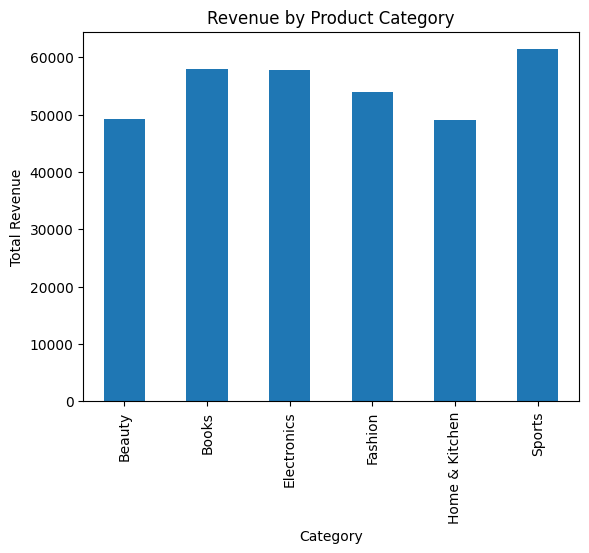

In [43]:
category_sales.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.show()

**Profit by Category Chart** – Plots a bar chart showing the total profit generated by each product category.


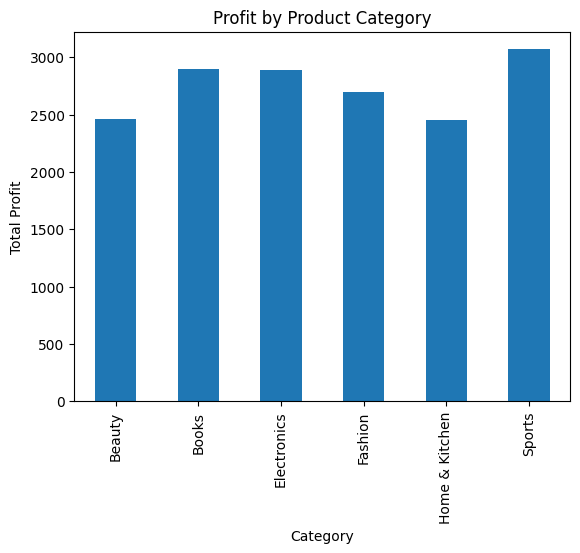

In [44]:
profit_category = df.groupby("product_category")["profit"].sum()

profit_category.plot(kind="bar")

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

**Region Sales Bar Chart** - Creates a bar chart to visualize total revenue generated from each region.

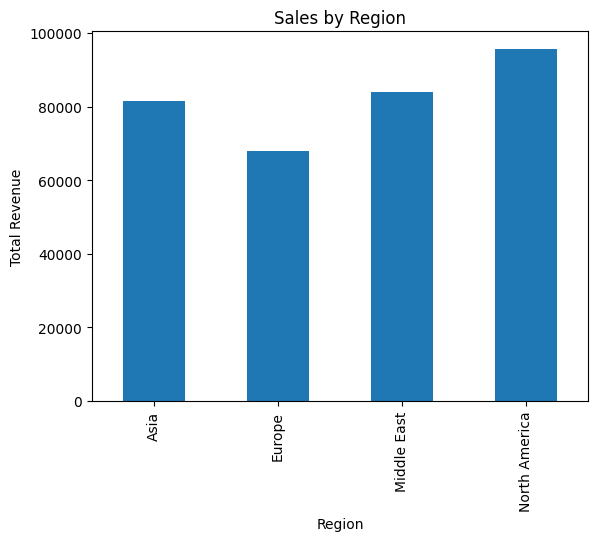

In [45]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.show()

**Customized Payment Distribution Chart** - Creates a colored pie chart to show the percentage distribution of each payment method.

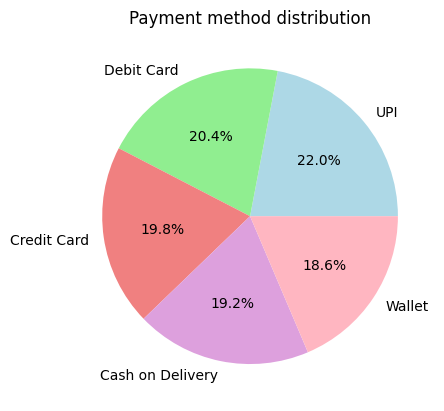

In [46]:
colors = ["lightblue", "lightgreen", "lightcoral", "plum", "lightpink"]
payment_count.plot(kind="pie", autopct="%1.1f%%",colors=colors)
plt.title("Payment method distribution")
plt.show()

**Donut Chart for Payment Methods** - Creates a donut chart to visualize the percentage distribution of different payment methods.

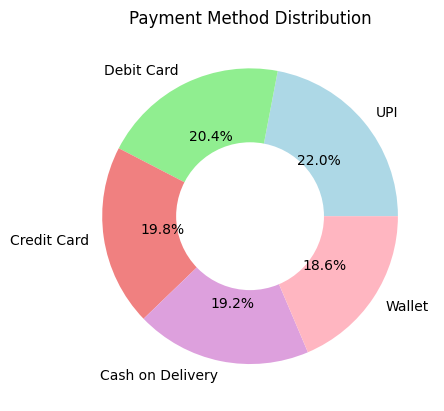

In [47]:
colors = ["lightblue", "lightgreen", "lightcoral", "plum", "lightpink"]

payment_count.plot(kind="pie", autopct="%1.1f%%", colors=colors)

centre_circle = plt.Circle((0,0),0.50,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Payment Method Distribution")
plt.show()

**Discount vs Revenue Scatter Plot** - Creates a scatter plot to show the relationship between discount percentage and total revenue for each product category.

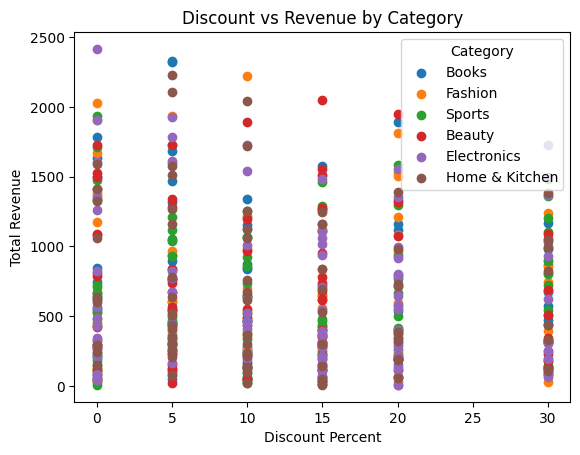

In [48]:
categories = df["product_category"].unique()

for cat in categories:
    data = df[df["product_category"] == cat]
    plt.scatter(data["discount_percent"], data["total_revenue"], label=cat)

plt.xlabel("Discount Percent")
plt.ylabel("Total Revenue")
plt.title("Discount vs Revenue by Category")

plt.legend(title="Category")

plt.show()

**Monthly Revenue Trend Chart** - Groups total revenue by month and plots a line chart to visualize monthly sales trends.

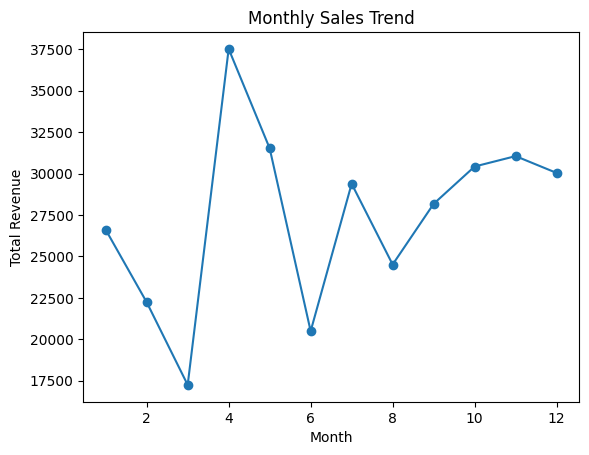

In [49]:
monthly_sales = df.groupby("month")["total_revenue"].sum()

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.show()

**Monthly Sales Trend** - Groups revenue by month and plots a line chart to show how sales change over time.

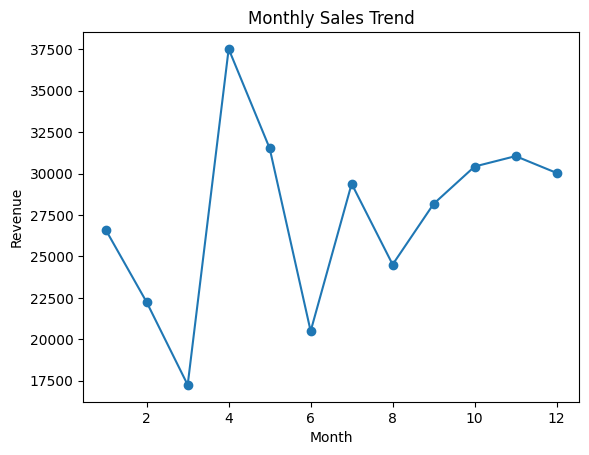

In [50]:
monthly_sales = df.groupby("month")["total_revenue"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

**Profit by Category** - Groups data by product category and plots a bar chart of total profit for each category.

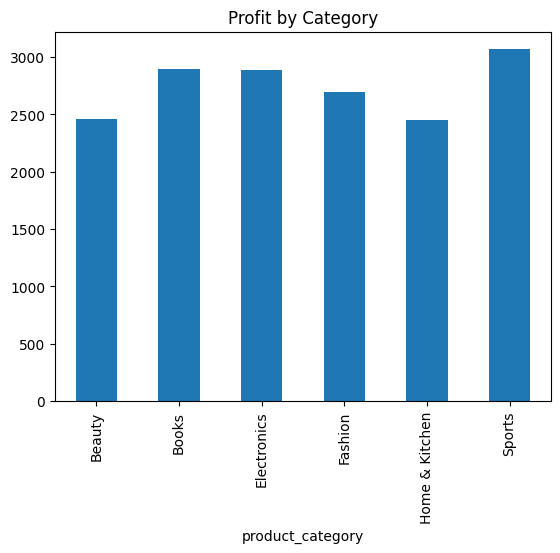

In [51]:
profit_category = df.groupby("product_category")["profit"].sum()

profit_category.plot(kind="bar")
plt.title("Profit by Category")
plt.show()

**Top 10 Products Revenue Chart** – Displays a bar chart of the top 10 products with the highest total revenue.


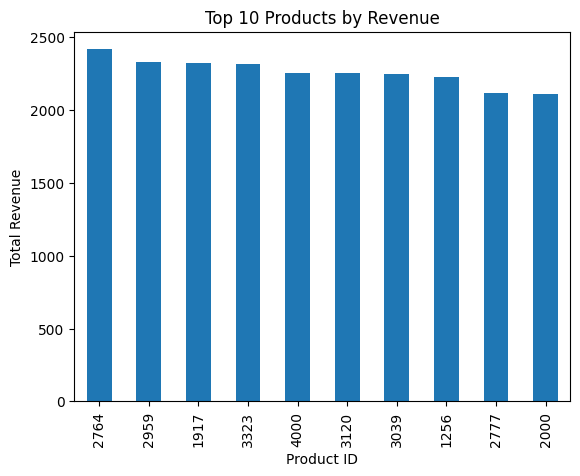

In [52]:
top_products = df.groupby("product_id")["total_revenue"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Total Revenue")

plt.show()

**Correlation Heatmap** - Displays a heatmap showing the correlation between numerical columns in the dataset.

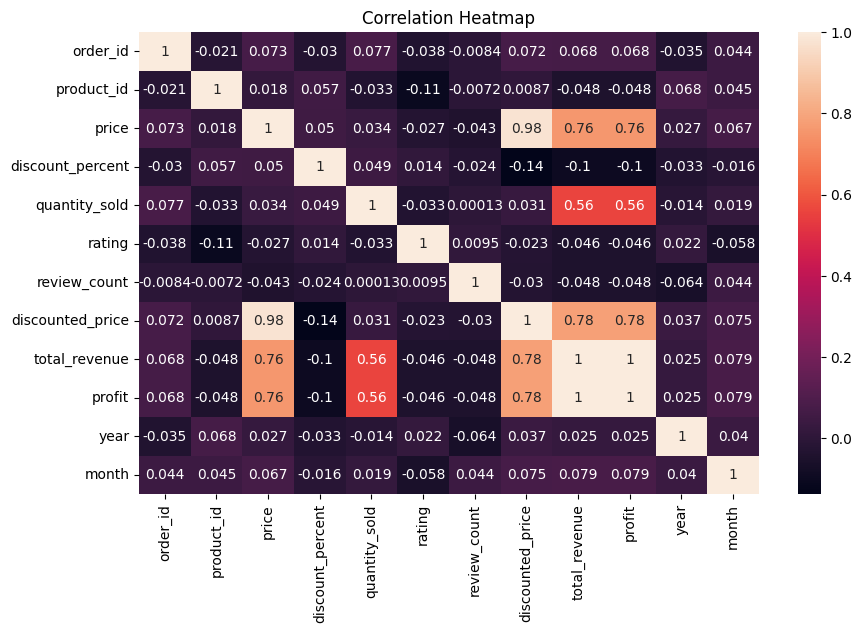

In [53]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Top Products by Revenue** - Identifies the top 10 products with the highest total revenue and displays them in a bar chart.

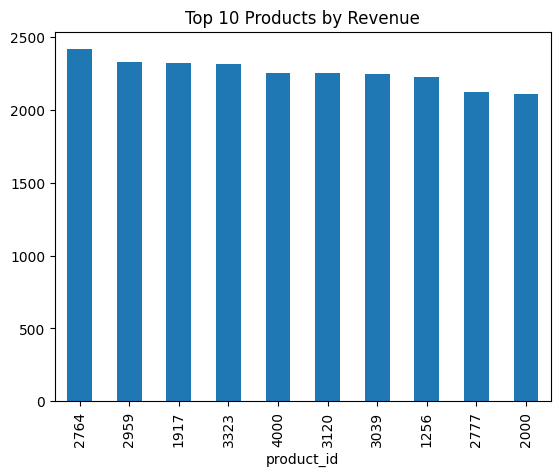

In [54]:
top_products = df.groupby("product_id")["total_revenue"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.show()

**Discount vs Profit Scatter Plot** - Plots a scatter chart to show the relationship between discount percentage and profit.

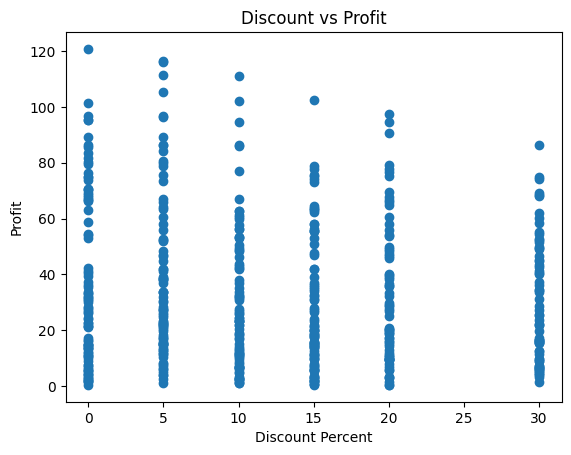

In [55]:
plt.scatter(df["discount_percent"], df["profit"])
plt.xlabel("Discount Percent")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

**Rating vs Revenue Scatter Plot** – Shows the relationship between product ratings and total revenue using a scatter plot.


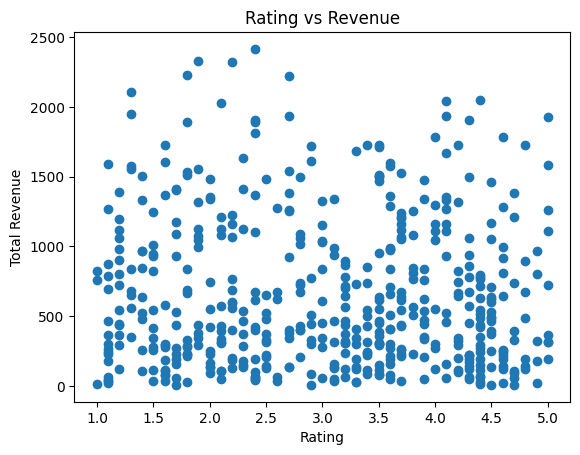

In [56]:
plt.scatter(df["rating"], df["total_revenue"])

plt.xlabel("Rating")
plt.ylabel("Total Revenue")

plt.title("Rating vs Revenue")

plt.show()

**Rating vs Revenue Scatter Plot** - Plots a scatter chart to show the relationship between product ratings and total revenue.

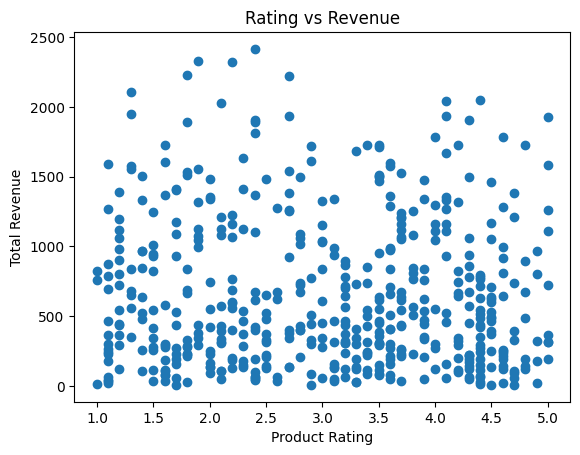

In [57]:
plt.scatter(df["rating"], df["total_revenue"])
plt.xlabel("Product Rating")
plt.ylabel("Total Revenue")
plt.title("Rating vs Revenue")
plt.show()

**Quantity Sold by Category** - Groups data by product category and plots a bar chart of total quantity sold for each category.

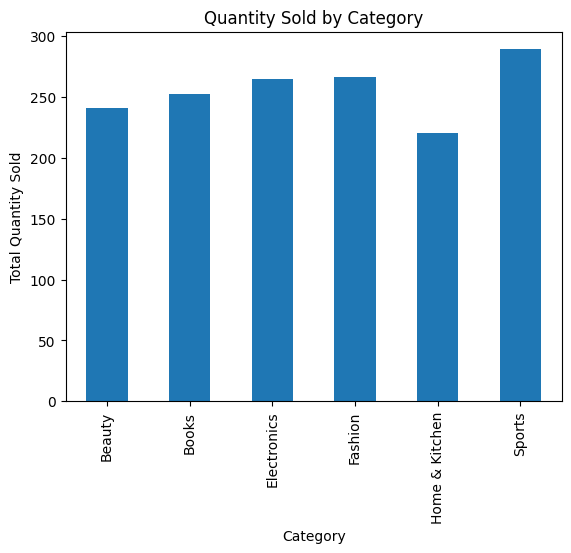

In [58]:
category_quantity = df.groupby("product_category")["quantity_sold"].sum()

category_quantity.plot(kind="bar")
plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity Sold")
plt.show()

**Average Rating by Category Chart** - Plots a bar chart showing the average product rating for each category.

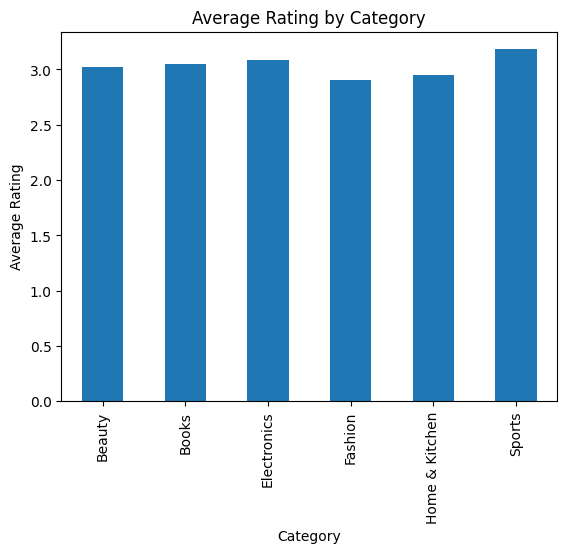

In [59]:
avg_rating = df.groupby("product_category")["rating"].mean()

avg_rating.plot(kind="bar")
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.show()

**Correlation Heatmap** – Visualizes the correlation between numerical columns using a heatmap.


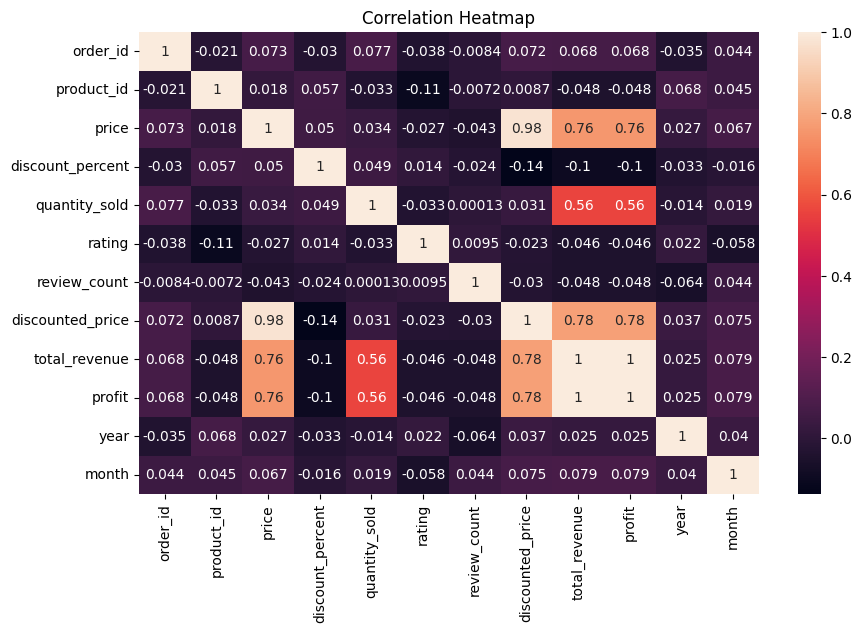

In [60]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

Key Insights:

• Electronics and Sports categories generate high revenue.

• North America contributes the largest share of sales.

• Discounts increase product purchases but reduce profit margins.

• Higher rated products tend to generate better revenue.

• Some products generate significantly higher revenue than others.